In [8]:
!pip install ultralytics
!pip install matplotlib opencv-python
!pip install numpy

In [9]:
!pip install lime

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [11]:
# মডেল লোড
model = YOLO("/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/best.pt")

# একটি নির্দিষ্ট ইমেজ পাথ (যেখানে ফ্র্যাকচার আছে)
img_path = "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/115_jpg.rf.e502e3b728f83a17a782892ab3edae06.jpg"

def read_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (640, 640))
    return img

image = read_and_preprocess(img_path)

In [12]:
def predict_fn(images):
    # LIME অনেকগুলো ছোট ছোট ইমেজ (perturbed images) পাঠায়, সেগুলো লুপে প্রসেস করতে হয়
    results_list = []
    for img in images:
        # YOLO ইনপুট হিসেবে ০-১ রেঞ্জের ভ্যালু পছন্দ করে
        res = model.predict(img, conf=0.1, verbose=False)
        
        # ডিফল্ট স্কোর ০ (যদি কিছু ডিটেক্ট না হয়)
        probs = np.zeros(2) # ধরি ২টা স্টেট: ০ (সুস্থ), ১ (ফ্র্যাকচার)
        
        if len(res[0].boxes) > 0:
            # সর্বোচ্চ কনফিডেন্স স্কোরটি নেওয়া হচ্ছে
            max_conf = res[0].boxes.conf.cpu().numpy().max()
            probs[1] = max_conf
            probs[0] = 1 - max_conf
        else:
            probs[0] = 1.0
            
        results_list.append(probs)
    
    return np.array(results_list)

  0%|          | 0/500 [00:00<?, ?it/s]

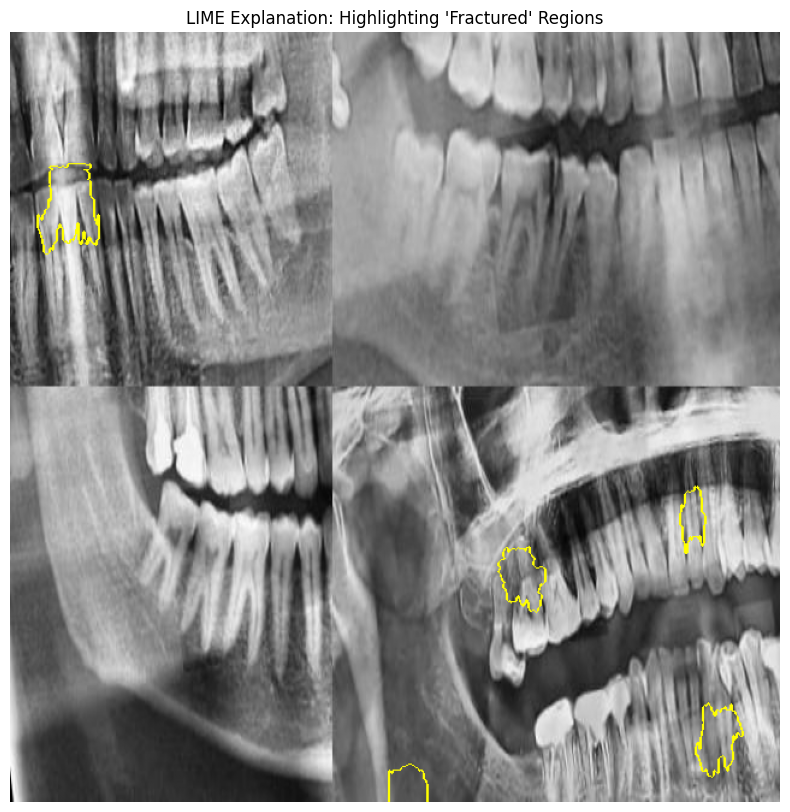

In [13]:
# LIME এক্সপ্লেইনার তৈরি
explainer = lime_image.LimeImageExplainer()

# ব্যাখ্যা তৈরি করা (এটি ২-৩ মিনিট সময় নিতে পারে)
explanation = explainer.explain_instance(
    image, 
    predict_fn, 
    top_labels=1, 
    hide_color=0, 
    num_samples=500 # নমুনার সংখ্যা বাড়ালে নির্ভুলতা বাড়ে
)

# পজিটিভ অংশগুলো (যা ফ্র্যাকচার নির্দেশ করে) মাস্ক হিসেবে বের করা
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)

# প্লটিং
plt.figure(figsize=(10, 10))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation: Highlighting 'Fractured' Regions")
plt.axis('off')
plt.show()